In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
f14a03r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r1.nc')
f14a03r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r2.nc')
f14a03r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r3.nc')

f14a02r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r1.nc')
f14a02r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r2.nc')
f14a02r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r3.nc')

f14a01r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r1.nc')
f14a01r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r2.nc')
f14a01r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r3.nc')

In [88]:
x = f14a03r1.x.values
z = f14a03r1.z.values

In [89]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

def x_phys_formatter(x_tick, pos):
        # Map image x → physical x (paddle at 8.06 m on the right)
        return f"{8.06 + (x_max - x_tick):.2f}"

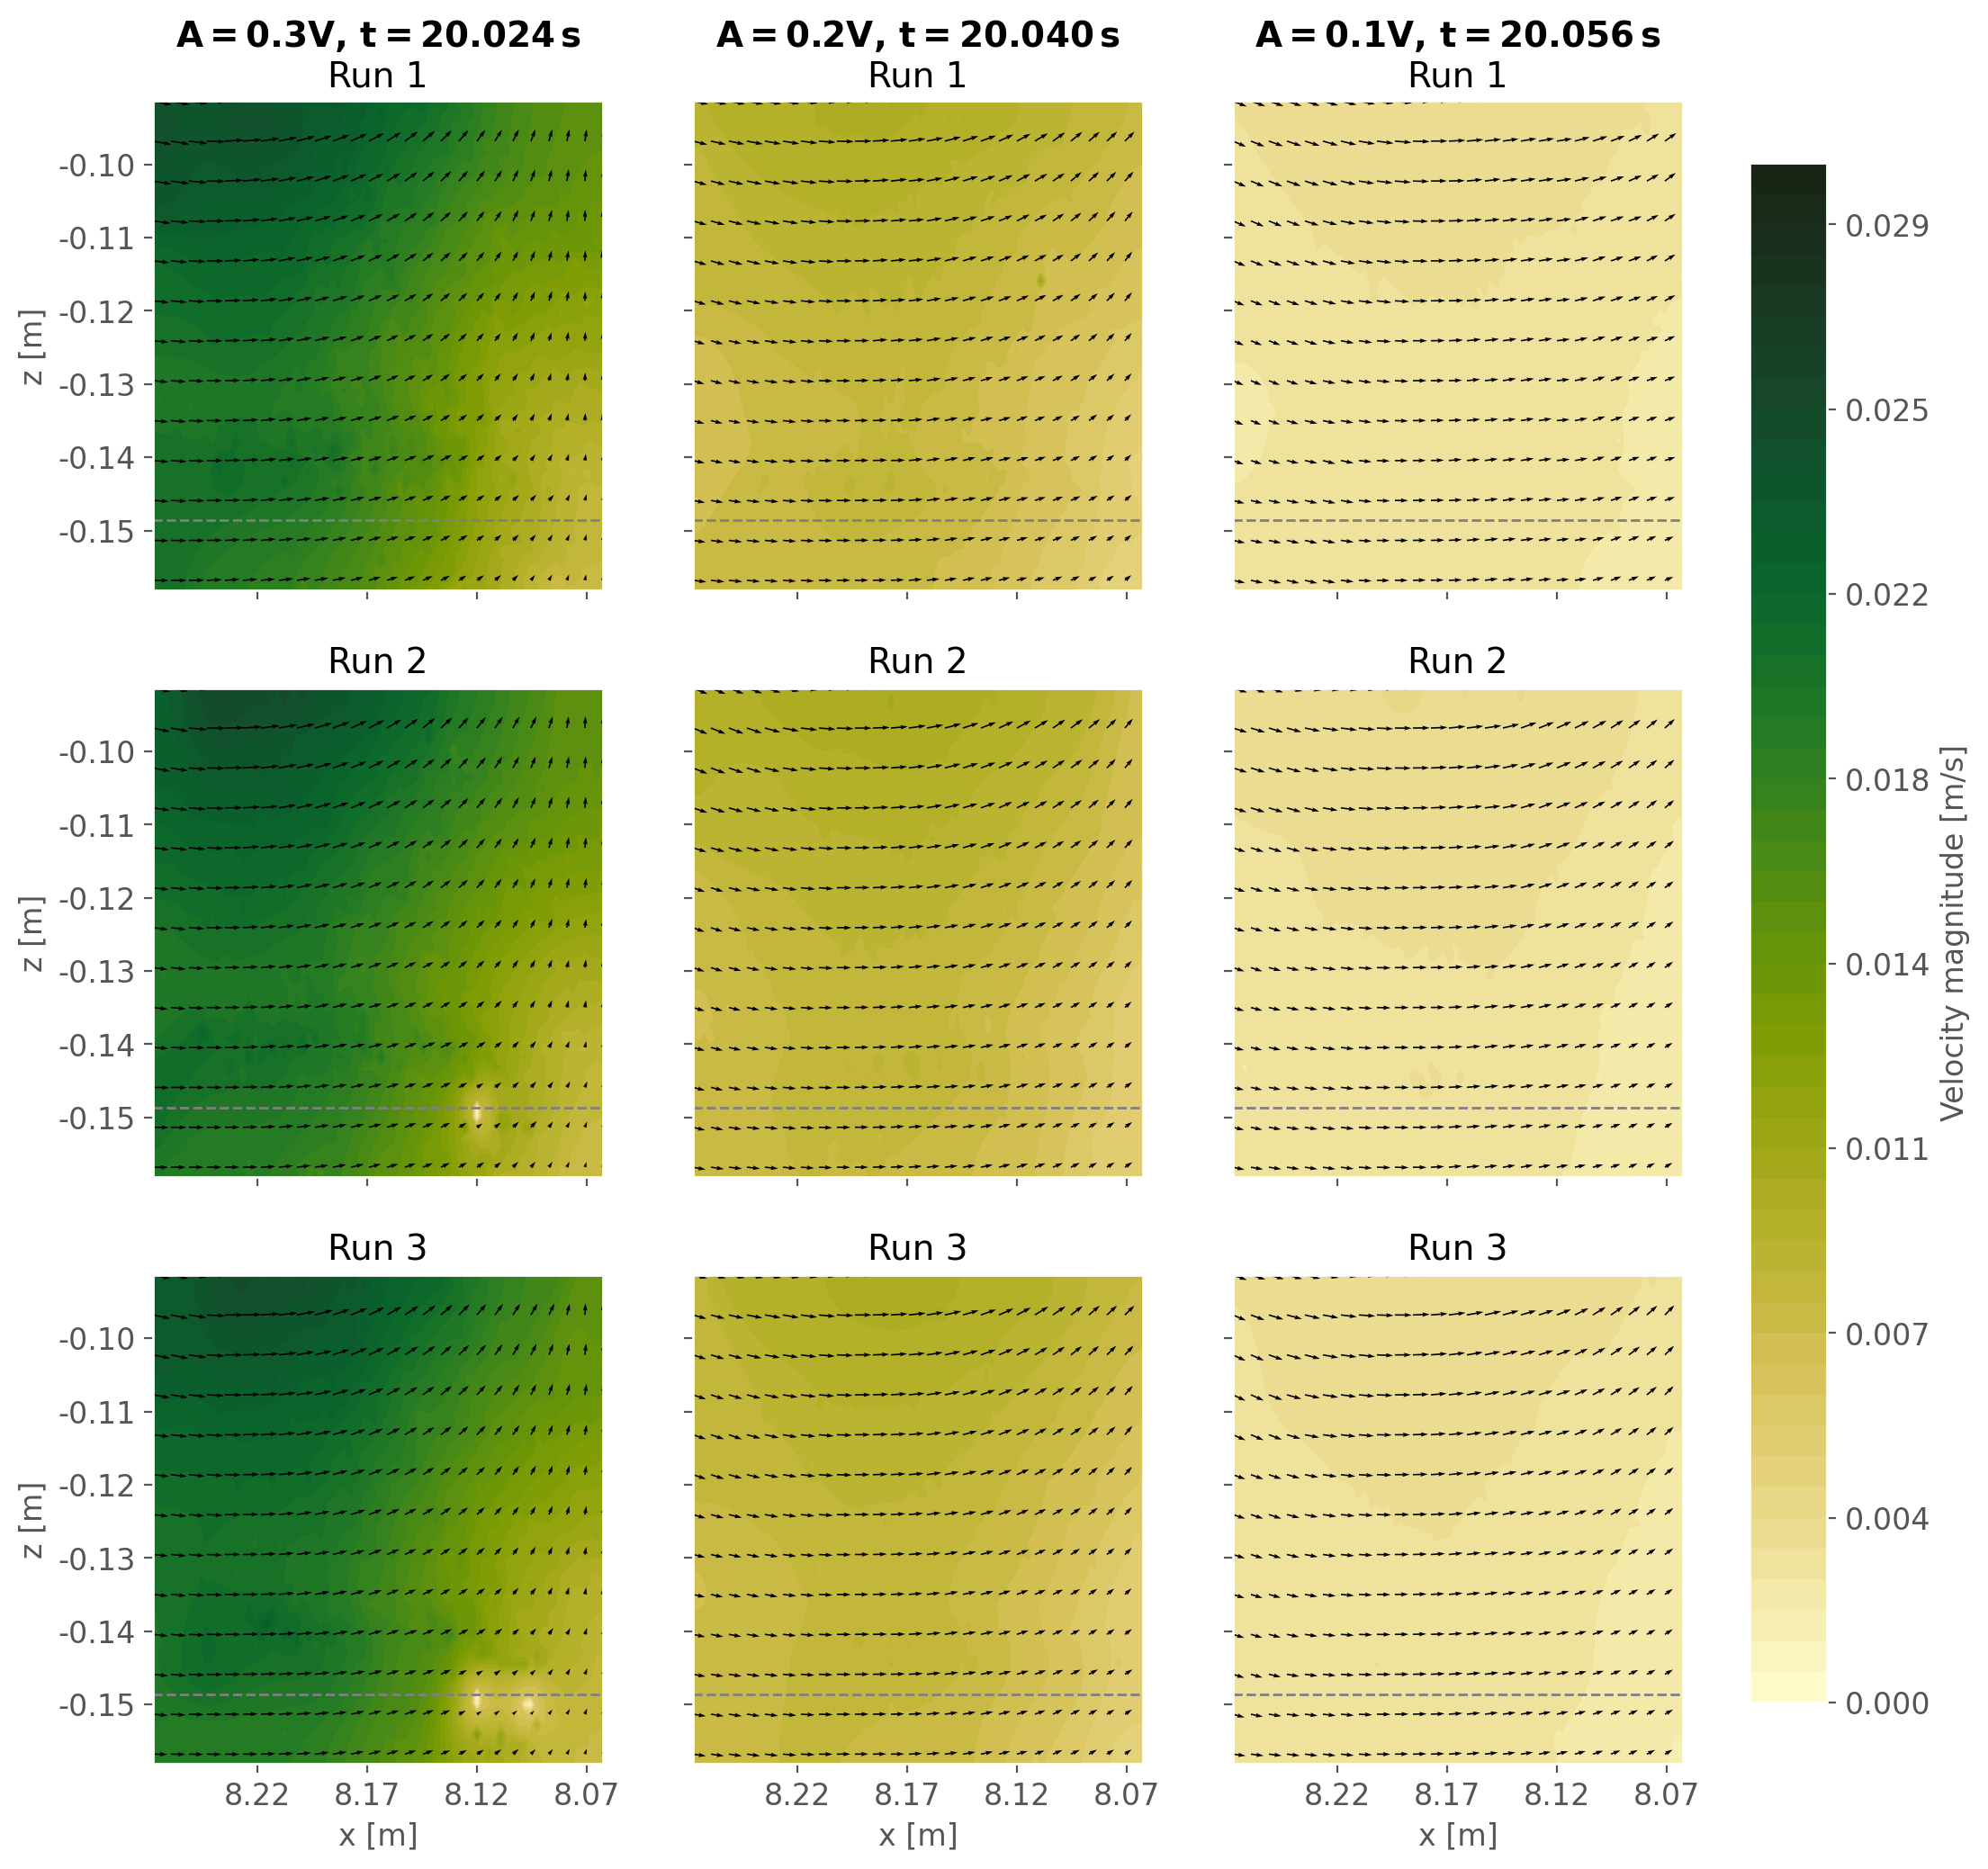

In [129]:
# Decimal for colorbars
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.3f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = 0
umax = 0.03

# Subsampling steps for quiver plot
step_x = 3
step_z = 4

im = ax[0, 0].contourf(x, z, np.sqrt(f14a03r1.u.values[0, :, :]**2 + f14a03r1.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[0, 0].quiver(x[::step_x], z[::step_z], -f14a03r1.u.values[0, ::step_z, ::step_x], f14a03r1.w.values[0, ::step_z, ::step_x])
ax[1, 0].contourf(x, z, np.sqrt(f14a03r2.u.values[0, :, :]**2 + f14a03r2.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[1, 0].quiver(x[::step_x], z[::step_z], -f14a03r2.u.values[0, ::step_z, ::step_x], f14a03r2.w.values[0, ::step_z, ::step_x])
ax[2, 0].contourf(x, z, np.sqrt(f14a03r3.u.values[0, :, :]**2 + f14a03r3.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[2, 0].quiver(x[::step_x], z[::step_z], -f14a03r3.u.values[0, ::step_z, ::step_x], f14a03r3.w.values[0, ::step_z, ::step_x])

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, np.sqrt(f14a02r1.u.values[0, :, :]**2 + f14a02r1.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[0, 1].quiver(x[::step_x], z[::step_z], -f14a02r1.u.values[0, ::step_z, ::step_x], f14a02r1.w.values[0, ::step_z, ::step_x])
ax[1, 1].contourf(x, z, np.sqrt(f14a02r2.u.values[0, :, :]**2 + f14a02r2.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[1, 1].quiver(x[::step_x], z[::step_z], -f14a02r2.u.values[0, ::step_z, ::step_x], f14a02r2.w.values[0, ::step_z, ::step_x])
ax[2, 1].contourf(x, z, np.sqrt(f14a02r3.u.values[0, :, :]**2 + f14a02r3.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[2, 1].quiver(x[::step_x], z[::step_z], -f14a02r3.u.values[0, ::step_z, ::step_x], f14a02r3.w.values[0, ::step_z, ::step_x])

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, np.sqrt(f14a01r1.u.values[0, :, :]**2 + f14a01r1.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[0, 2].quiver(x[::step_x], z[::step_z], -f14a01r1.u.values[0, ::step_z, ::step_x], f14a01r1.w.values[0, ::step_z, ::step_x])
ax[1, 2].contourf(x, z, np.sqrt(f14a01r2.u.values[0, :, :]**2 + f14a01r2.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[1, 2].quiver(x[::step_x], z[::step_z], -f14a01r2.u.values[0, ::step_z, ::step_x], f14a01r2.w.values[0, ::step_z, ::step_x])
ax[2, 2].contourf(x, z, np.sqrt(f14a01r3.u.values[0, :, :]**2 + f14a01r3.w.values[0, :, :]**2), levels=np.linspace(umin, umax, 51), cmap=cmo.speed)
ax[2, 2].quiver(x[::step_x], z[::step_z], -f14a01r3.u.values[0, ::step_z, ::step_x], f14a01r3.w.values[0, ::step_z, ::step_x])

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='gray', linestyles='dashed', linewidth=1)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", extend='max', fraction=0.046, pad=0.04, **kwargs)
cbar.set_label("Velocity magnitude [m/s]")  # adjust label as needed


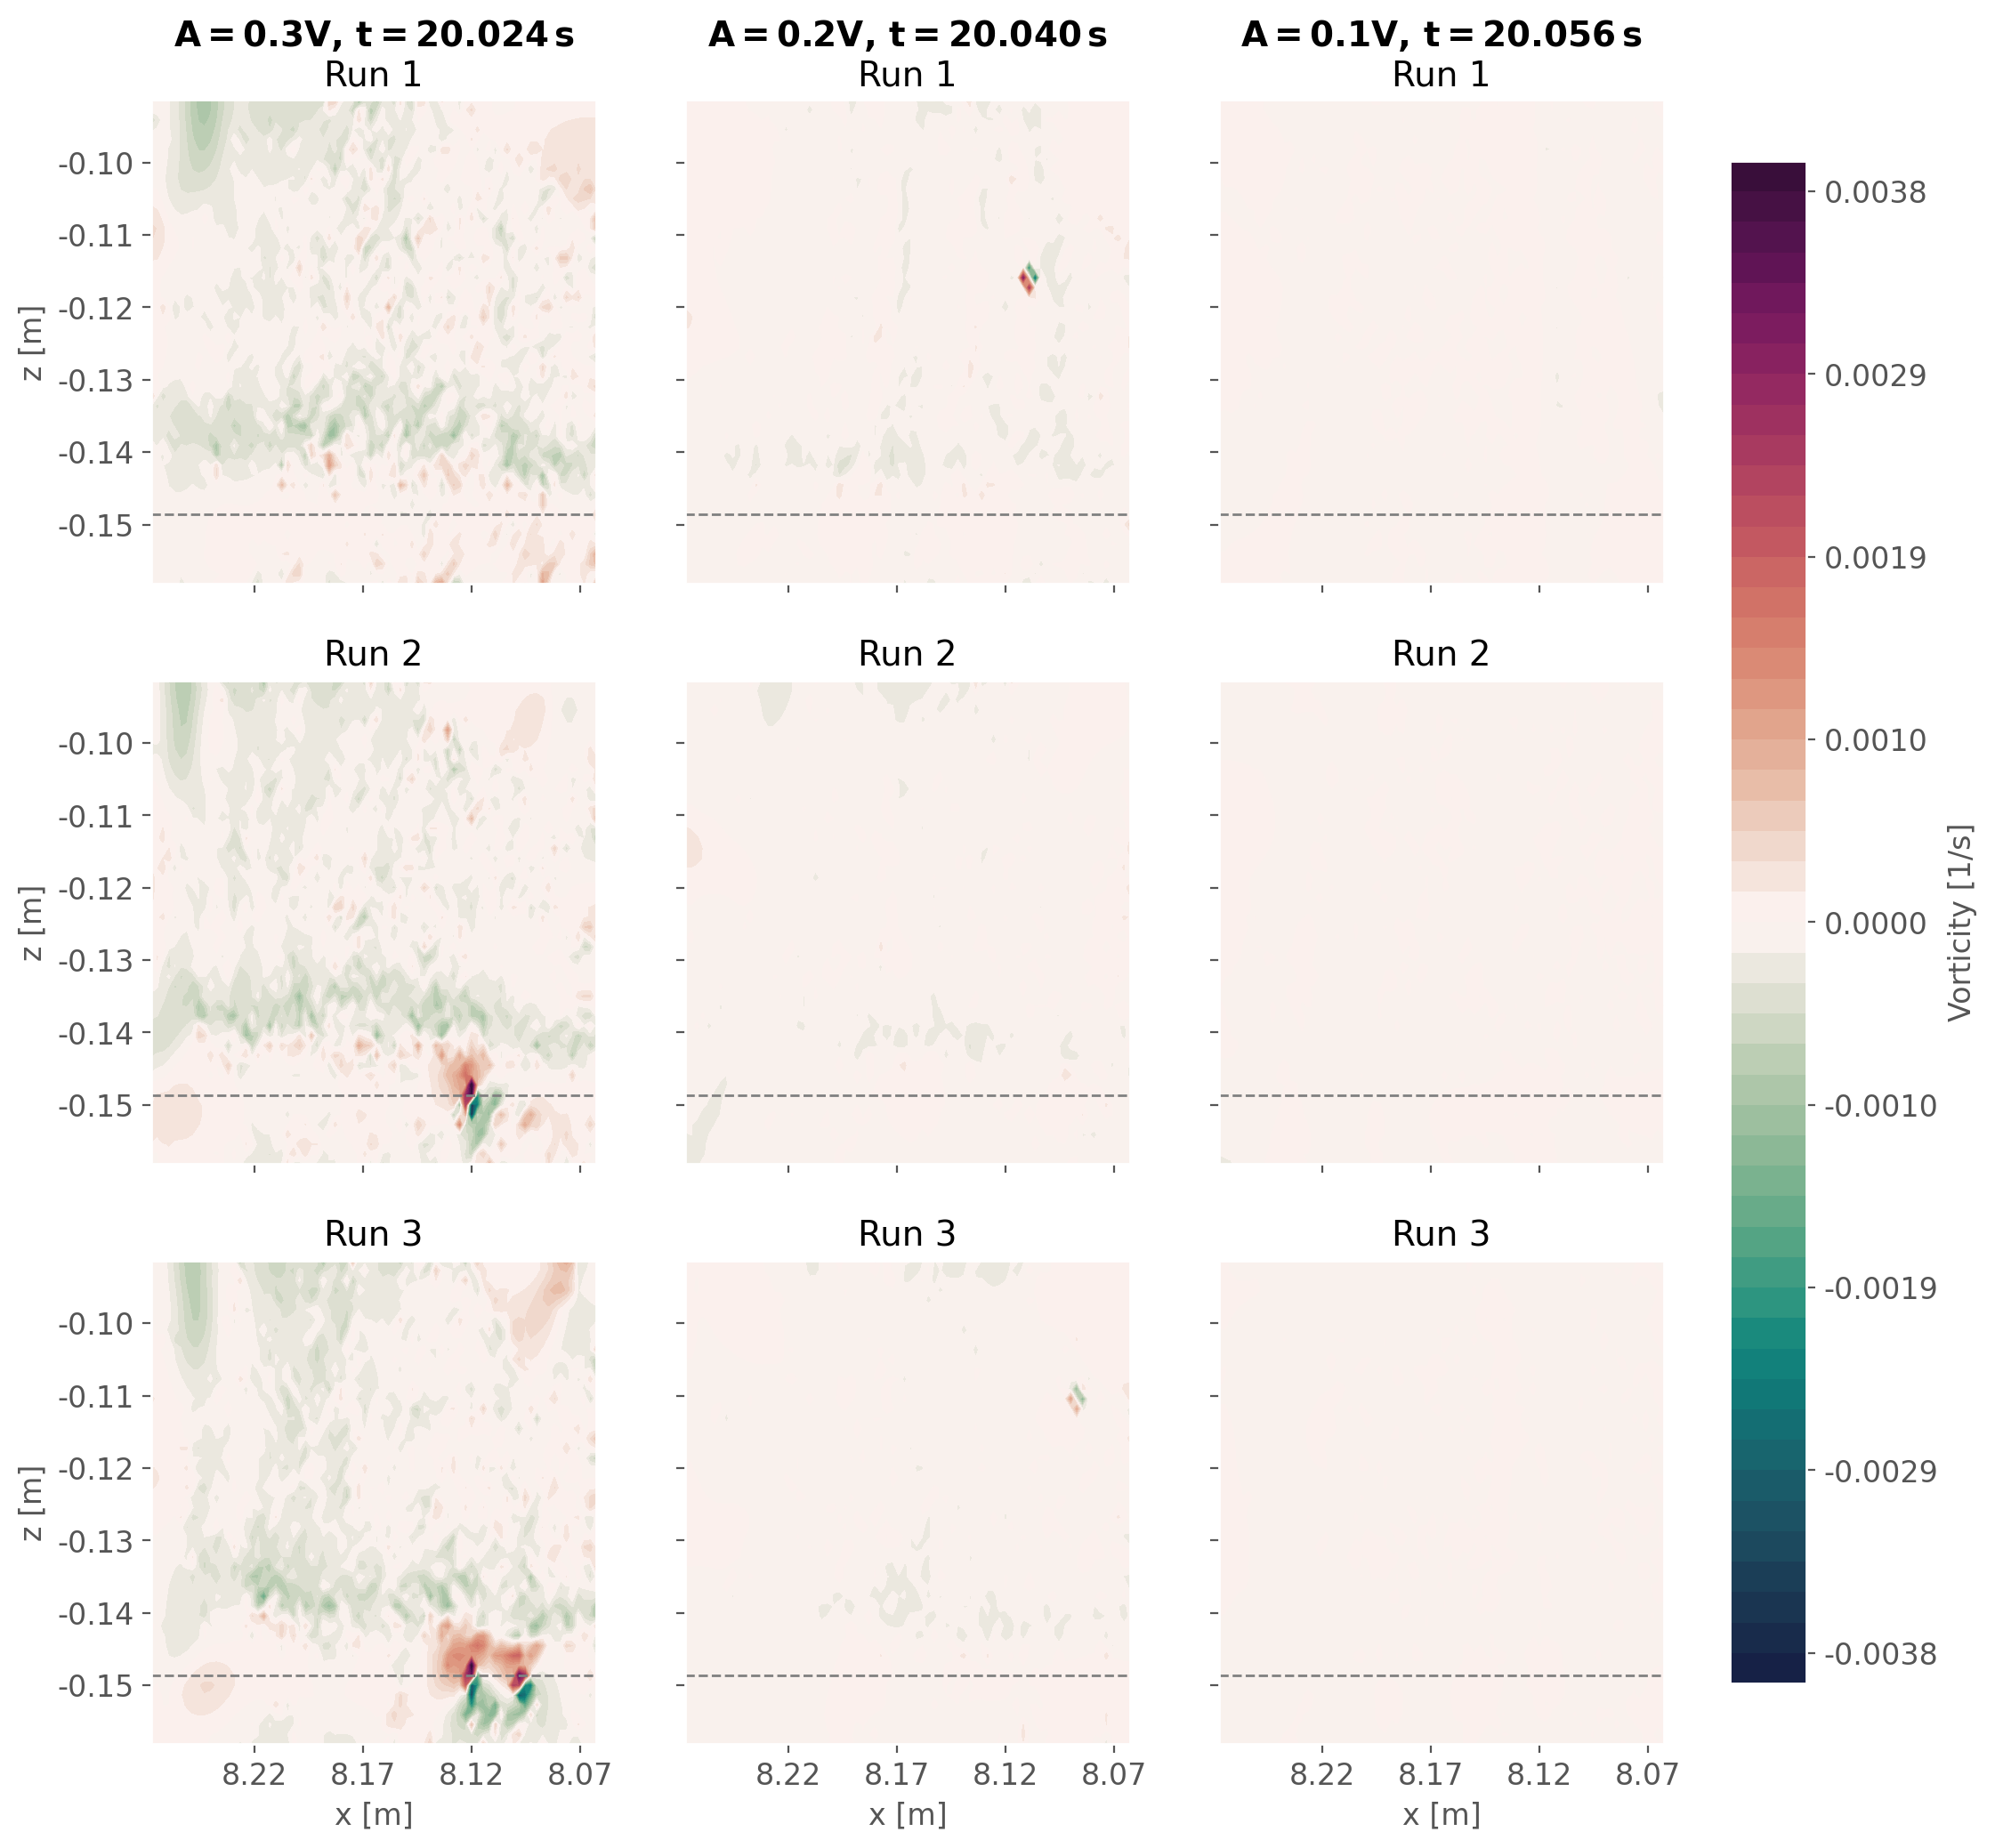

In [130]:
# Decimal for colorbars
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.4f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = -0.004
umax = 0.004

# Subsampling steps for quiver plot
step_x = 3
step_z = 4

im = ax[0, 0].contourf(x, z, f14a03r1['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[1, 0].contourf(x, z, f14a03r2['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[2, 0].contourf(x, z, f14a03r3['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, f14a02r1['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[1, 1].contourf(x, z, f14a02r2['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[2, 1].contourf(x, z, f14a02r3['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, f14a01r1['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[1, 2].contourf(x, z, f14a01r2['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)
ax[2, 2].contourf(x, z, f14a01r3['vorticity'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.curl)

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='gray', linestyles='dashed', linewidth=1)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.046, pad=0.04,**kwargs)
cbar.set_label("Vorticity [1/s]")  # adjust label as needed

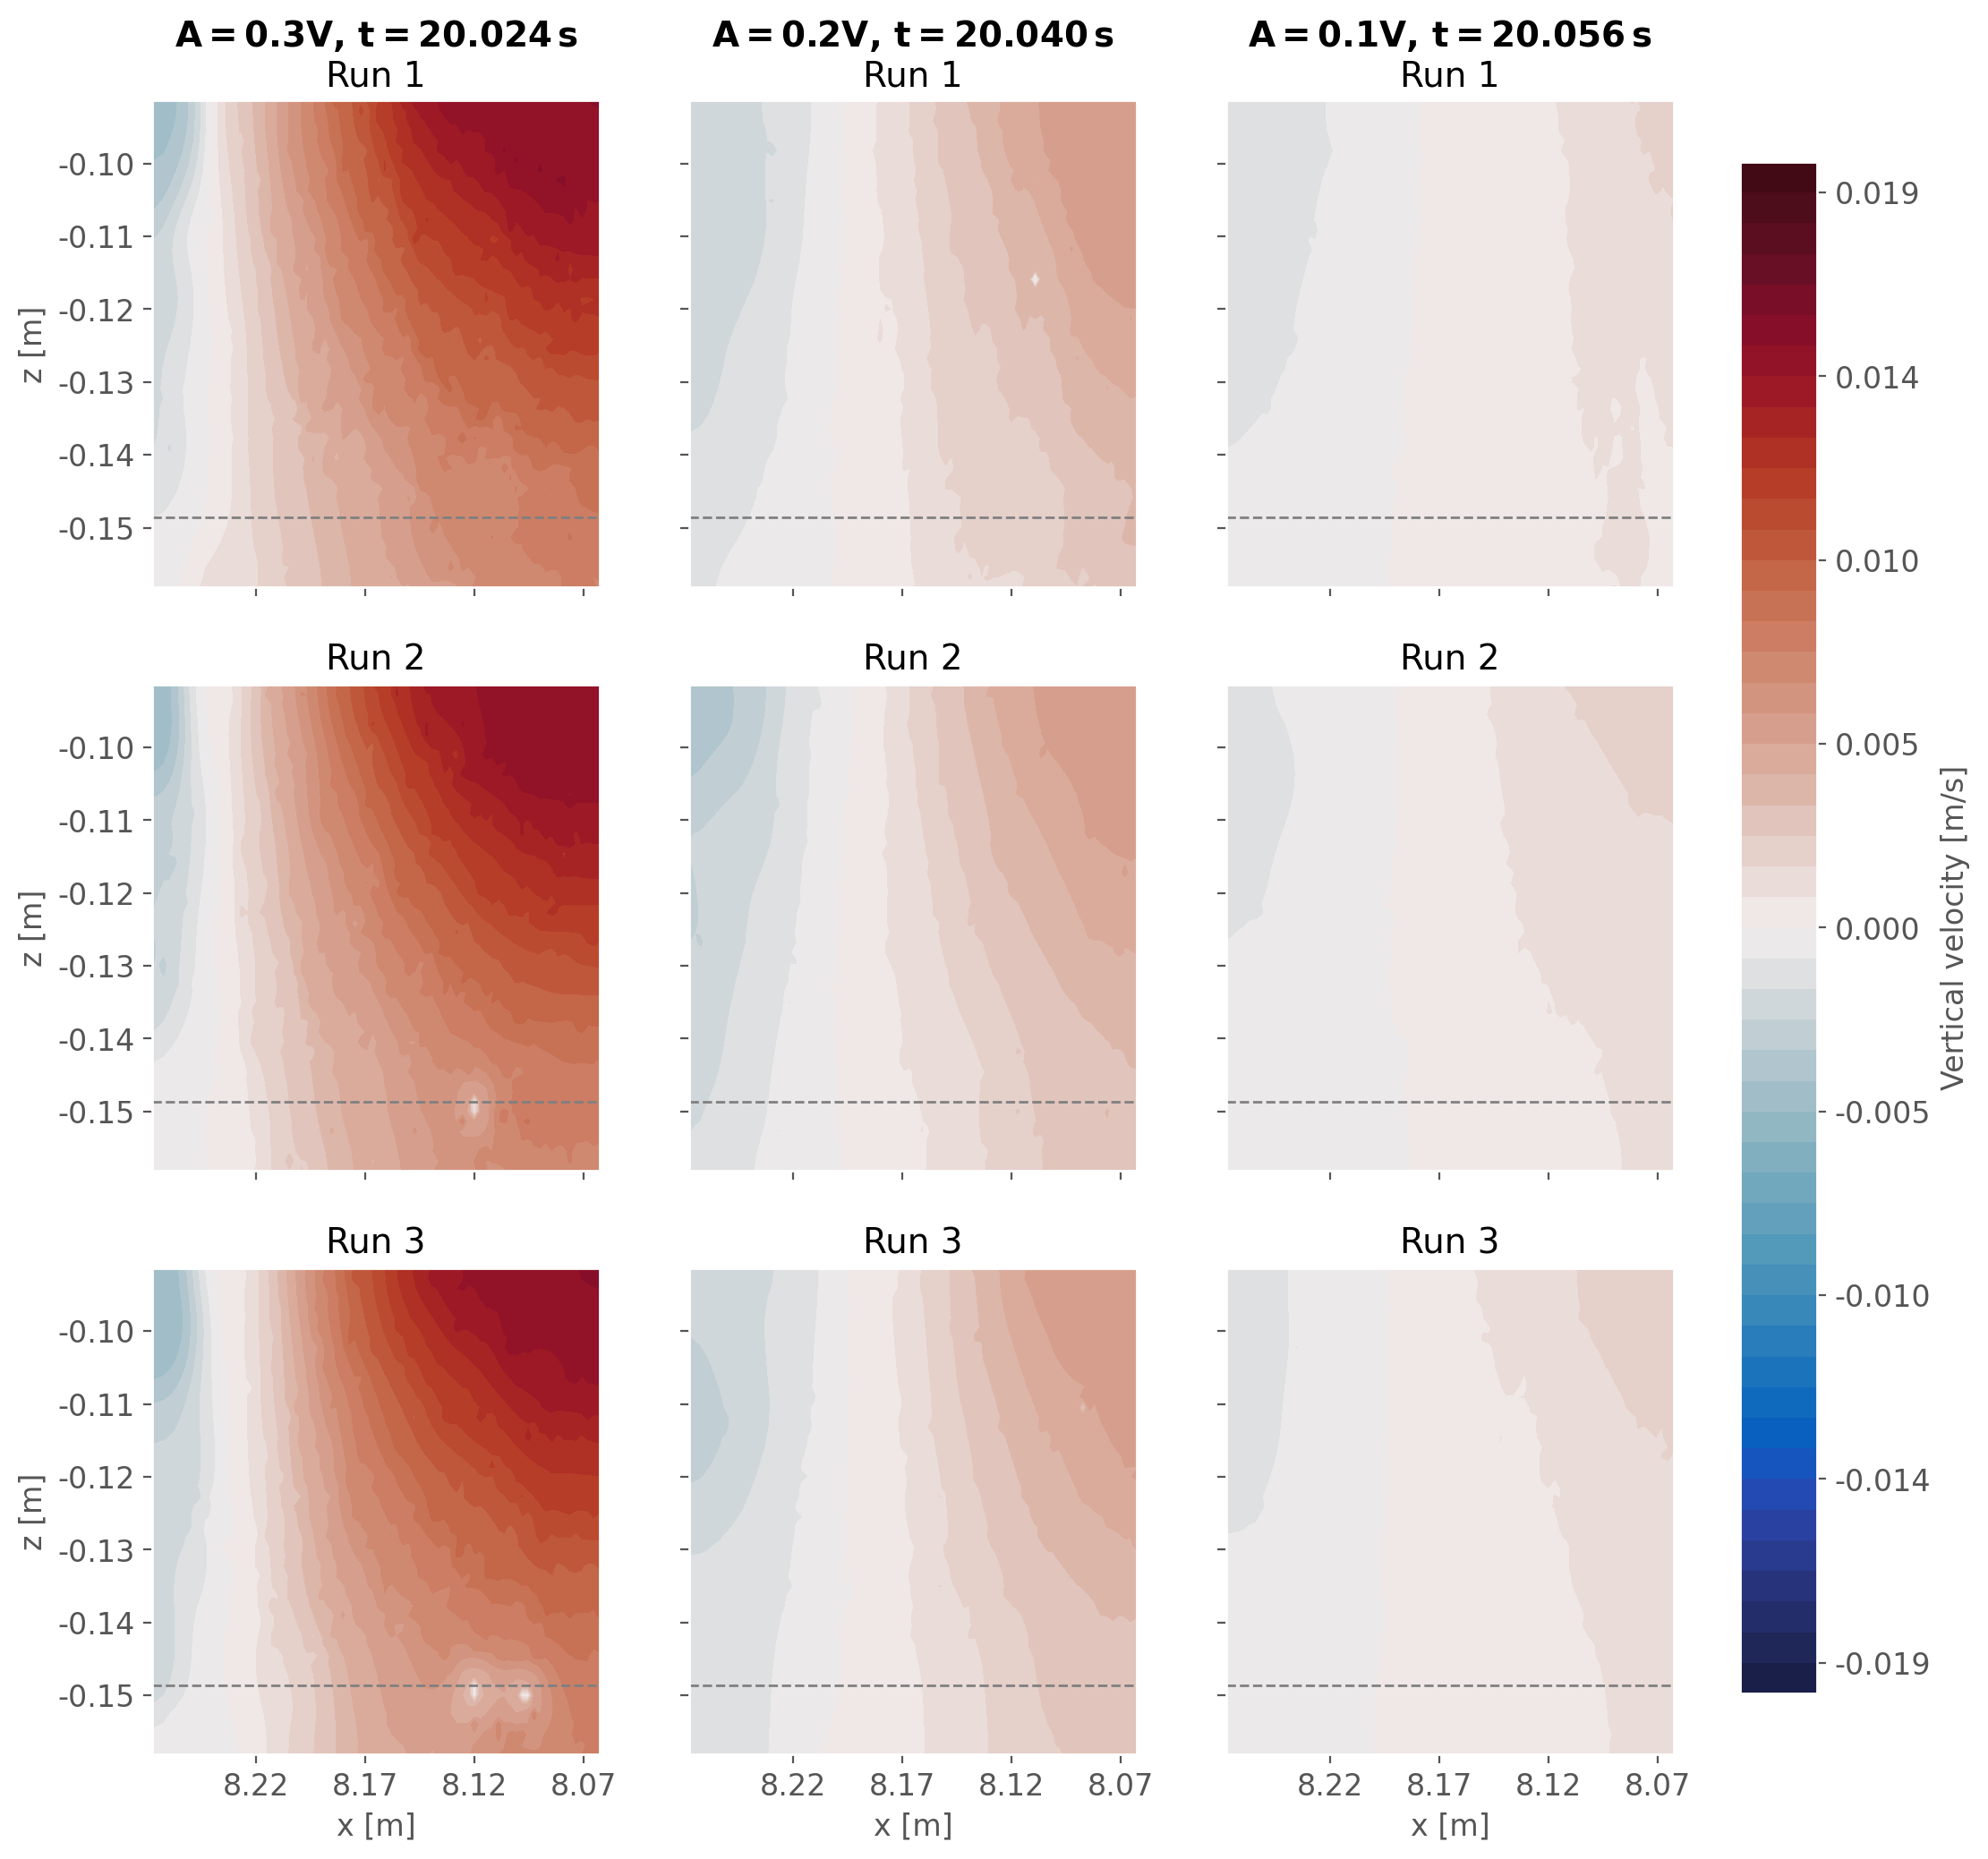

In [131]:
# Decimal for colorbars
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.3f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = -0.02
umax = 0.02

# Subsampling steps for quiver plot
step_x = 3
step_z = 4

im = ax[0, 0].contourf(x, z, f14a03r1['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[1, 0].contourf(x, z, f14a03r2['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[2, 0].contourf(x, z, f14a03r3['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, f14a02r1['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[1, 1].contourf(x, z, f14a02r2['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[2, 1].contourf(x, z, f14a02r3['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, f14a01r1['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[1, 2].contourf(x, z, f14a01r2['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)
ax[2, 2].contourf(x, z, f14a01r3['w'][0, :, :], levels=np.linspace(umin, umax, 51), cmap=cmo.balance)

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][0]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='gray', linestyles='dashed', linewidth=1)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.046, pad=0.04, **kwargs)
cbar.set_label("Vertical velocity [m/s]")  # adjust label as needed